# outlier analysis

- we inderstood emperical rule failed

- then we plotted histogram its slightly deviated

- so it indicates the data has outliers

- outliers can be shown by the box plot

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
visadf = pd.read_csv("Visadataset.csv")

In [5]:
wagedata = visadf['prevailing_wage']

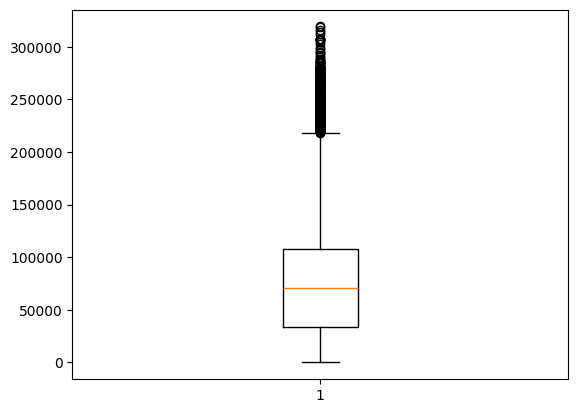

In [9]:
plt.boxplot(wagedata)
plt.show()

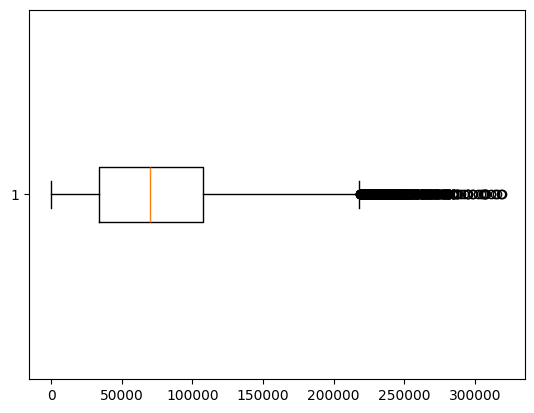

In [10]:
plt.boxplot(wagedata,vert=False)
plt.show()


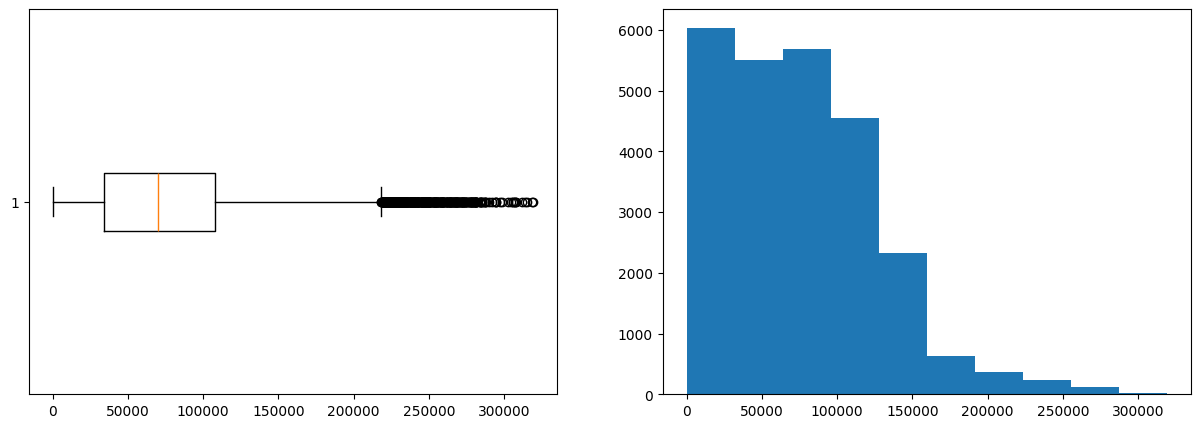

In [16]:
plt.figure(figsize=(15,5))
plt.subplot(1,2,1).boxplot(wagedata,vert=False)
plt.subplot(1,2,2).hist(wagedata)
plt.show()


In [19]:
visadf['prevailing_wage'].describe()

count     25480.000000
mean      74455.814592
std       52815.942327
min           2.136700
25%       34015.480000
50%       70308.210000
75%      107735.512500
max      319210.270000
Name: prevailing_wage, dtype: float64

In [71]:
q1 = np.percentile(wagedata,25)
q2  = np.percentile(wagedata,50)
q3 = np.percentile(wagedata,75)

iqr = q3 -q1

ub = q3 + 1.5* iqr

lb = q3 - 1.5*iqr

con1 = wagedata > ub
con2 = wagedata < lb

con = con1|con2

outliersdf = visadf[con]
len(outliersdf)

427

# non outliers

In [72]:
q1 = np.percentile(wagedata,25)
q2  = np.percentile(wagedata,50)
q3 = np.percentile(wagedata,75)

iqr = q3 -q1

ub = q3 + 1.5* iqr

lb = q3 - 1.5*iqr

con1 = wagedata < ub
con2 = wagedata > lb

con = con1 & con2

non_outliersdf = visadf[con]
len(non_outliersdf)

25053

# fill the outliers

- drop is not recommended

# types

- dop the outliers

- fill with meadian

- winsoration = will with LB and UB

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified
...,...,...,...,...,...,...,...,...,...,...,...,...
25474,EZYV25475,Africa,Doctorate,N,N,2594,1979,Northeast,51104.7800,Year,Y,Certified
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified


In [76]:
outliersdf
outliersdf['prevailing_wage']
outliersdf['prevailing_wage'].values
outerliers =  outliersdf['prevailing_wage'].values.tolist()
outliers_med = np.median(outerliers)
l = []
for value in wage_data:
    if value in outerliers:
        l.append(outliers_med)
    else:
        l.append(value)

In [90]:
visadf["prevailing_wage1"] = l 
visadf

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,prevailing_wage1
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,592.2029
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,83425.6500
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,122996.8600
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,83434.0300
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,149907.3900
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified,77092.5700
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified,243111.6100
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified,146298.8500
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified,86154.7700


{'whiskers': [<matplotlib.lines.Line2D at 0x1f21d11e350>,
 'caps': [<matplotlib.lines.Line2D at 0x1f21d11e5d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1f21d11e210>],
 'medians': [<matplotlib.lines.Line2D at 0x1f21d11e850>],
 'fliers': [<matplotlib.lines.Line2D at 0x1f21d11e990>],
 'means': []}

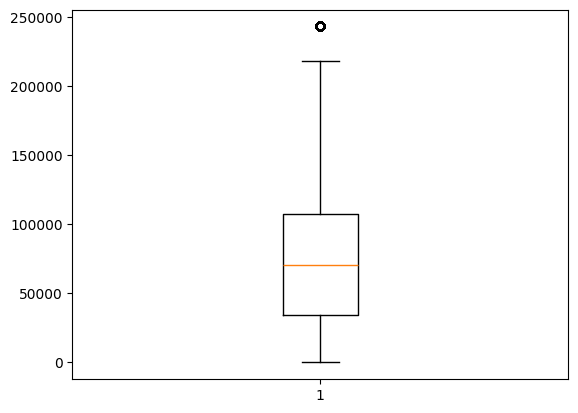

In [93]:
plt.boxplot(x=visadf["prevailing_wage1"],vert=True)

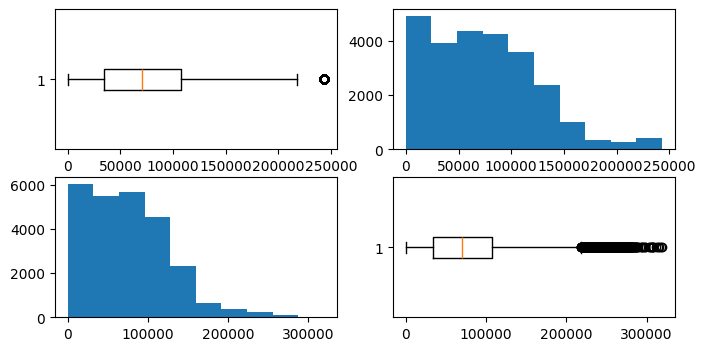

In [94]:
plt.figure(figsize=(8,4))
plt.subplot(2,2,1).boxplot(visadf['prevailing_wage1'],vert=False)
plt.subplot(2,2,2).hist(visadf['prevailing_wage1'])
plt.subplot(2,2,3).hist(wage_data)
plt.subplot(2,2,4).boxplot(wage_data,vert=False)
plt.show()


In [62]:
visadf['prevailing_wage'].describe()

count     25480.000000
mean      74455.814592
std       52815.942327
min           2.136700
25%       34015.480000
50%       70308.210000
75%      107735.512500
max      319210.270000
Name: prevailing_wage, dtype: float64

In [63]:
wage_data = visadf['prevailing_wage']
q1 = np.percentile(wagedata,25)
q2  = np.percentile(wagedata,50)
q3 = np.percentile(wagedata,75)

iqr = q3 -q1

ub = q3 + 1.5* iqr

lb = q3 - 1.5*iqr


visadf['prevailing_wage2'] = visadf['prevailing_wage'].clip(lower=lb , upper= ub)

In [64]:
visadf

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,prevailing_wage2
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,592.20290
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,83425.65000
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,122996.86000
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,83434.03000
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,149907.39000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified,77092.57000
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified,218315.56125
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified,146298.85000
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified,86154.77000


{'whiskers': [<matplotlib.lines.Line2D at 0x1f21c2eccd0>,
 'caps': [<matplotlib.lines.Line2D at 0x1f21c2ecf50>,
 'boxes': [<matplotlib.lines.Line2D at 0x1f21c2ecb90>],
 'medians': [<matplotlib.lines.Line2D at 0x1f21c2ed1d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1f21c2ed310>],
 'means': []}

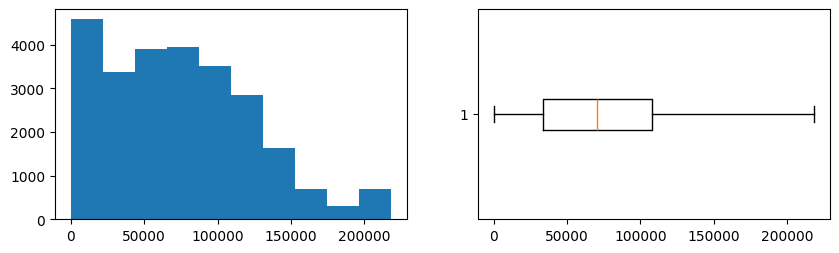

In [70]:
plt.figure(figsize=(10,6))
plt.subplot(2,2,1)
plt . hist(visadf['prevailing_wage2'])
plt.subplot(2,2,2)
plt.boxplot(x = visadf['prevailing_wage2'] , vert= False)

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [96]:
visadf = pd.read_csv("Visadataset.csv")

{'whiskers': [<matplotlib.lines.Line2D at 0x1f2214fa350>,
 'caps': [<matplotlib.lines.Line2D at 0x1f2214fa5d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x1f2214fa210>],
 'medians': [<matplotlib.lines.Line2D at 0x1f2214fa850>],
 'fliers': [<matplotlib.lines.Line2D at 0x1f2214fa990>],
 'means': []}

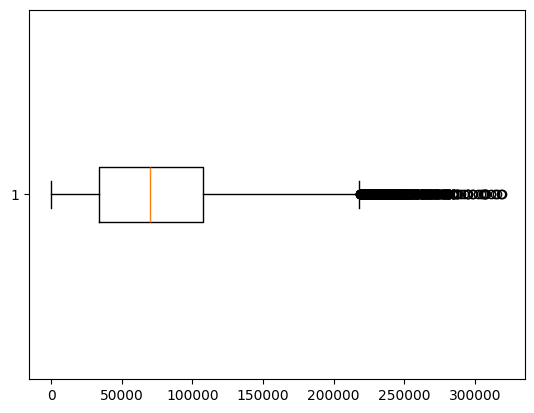

In [98]:
plt.boxplot(visadf['prevailing_wage'],vert=False)

# finding outliers

In [ ]:
q3 +  1.5 * iqr

In [99]:
visadf['prevailing_wage'].describe()

count     25480.000000
mean      74455.814592
std       52815.942327
min           2.136700
25%       34015.480000
50%       70308.210000
75%      107735.512500
max      319210.270000
Name: prevailing_wage, dtype: float64

In [104]:
q1 = 34015.480000
q2 = 70308.210000
q3 = 107735.512500

iqr = q3 - q1

upperbound = q3 + 1.5* iqr 

lowerbound = q3 - 1.5* iqr 

con1 = visadf['prevailing_wage'] < lowerbound

con2 = visadf['prevailing_wage'] > upperbound


con = con1 | con2

outliers_df = visadf[con]

len(outliers_df)


427

# dealing with median

In [108]:
outliers = outliers_df ['prevailing_wage'].values.tolist()

out_med = np.median(outliers)

wagedata = visadf['prevailing_wage']

l = []
for i in wagedata:
    if i in outliers:
        l.append(out_med)
    else:
        l.append(i)

In [111]:
visadf['prevailing_wage_median'] = l

In [112]:
visadf

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status,prevailing_wage_median
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied,592.2029
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified,83425.6500
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied,122996.8600
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied,83434.0300
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified,149907.3900
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.5700,Year,Y,Certified,77092.5700
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.7900,Year,Y,Certified,243111.6100
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.8500,Year,N,Certified,146298.8500
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.7700,Year,Y,Certified,86154.7700


# cap the values with q3 and q1 winsorization

In [115]:
visadf['prevailing_wage'].describe()

count     25480.000000
mean      74455.814592
std       52815.942327
min           2.136700
25%       34015.480000
50%       70308.210000
75%      107735.512500
max      319210.270000
Name: prevailing_wage, dtype: float64

In [116]:
q1 = np.percentile(visadf['prevailing_wage'],25)
q2 = np.percentile(visadf['prevailing_wage'],50)
q3 = np.percentile(visadf['prevailing_wage'],75)

iqr = q3 - q1

upperbound = q3 + 1.5*iqr
lowerbound = q3 - 1.5*iqr


win = visadf['prevailing_wage'].clip(lower= lowerbound , upper= upperbound)

visadf['prevailing_wage_winsorization'] = win


In [118]:
len(visadf)

25480